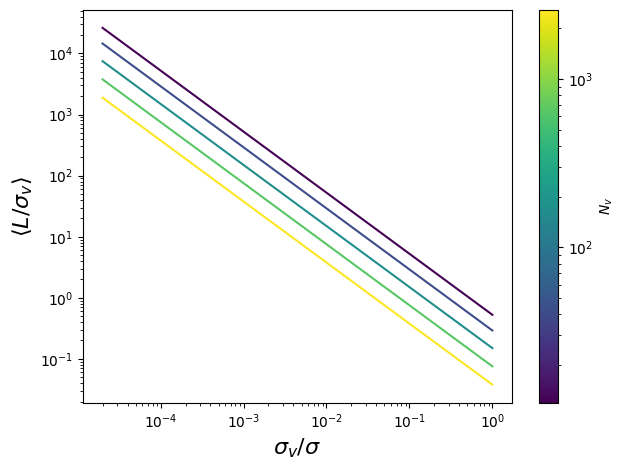

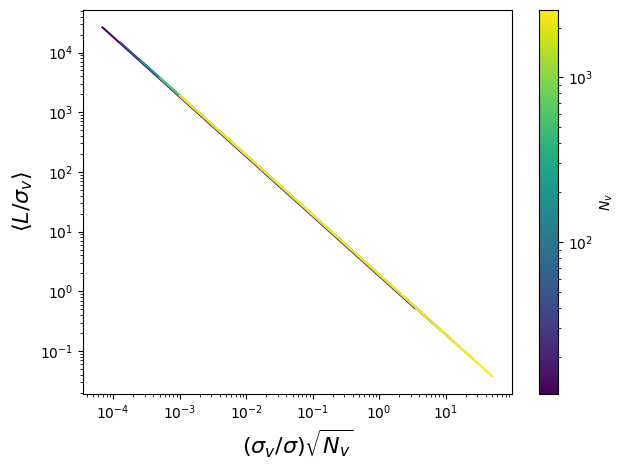

In [85]:
from matplotlib.colors import LogNorm
import trimesh
import numpy as np
import matplotlib.pyplot as plt

p_rad = 0.5
n_arad_points = 1000
max_subs = 5

meshes = [trimesh.creation.icosphere(subs, radius=p_rad) for subs in range(max_subs)]
nvs = [mesh.vertices.shape[0] for mesh in meshes]

cmap = plt.cm.viridis
nv_norm = LogNorm(min(nvs), max(nvs))

for mesh in meshes:
    edge_lengths = np.linalg.norm(np.diff(mesh.vertices[mesh.edges], axis=1).squeeze(), axis=-1)

    a_rad = np.linspace(0.00001, p_rad, n_arad_points + 1)[:-1]

    dimless_edge_lengths = edge_lengths / (2 * a_rad[:, None])

    nv = mesh.vertices.shape[0]

    plt.plot(a_rad / p_rad, np.mean(dimless_edge_lengths, axis=-1), c=cmap(nv_norm(nv)))

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\langle L / \sigma_v \rangle$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.tight_layout()
plt.savefig('figures-edge-length-scaling/ico-edge-lengths.png', dpi=600)
plt.show()



for mesh in meshes:
    edge_lengths = np.linalg.norm(np.diff(mesh.vertices[mesh.edges], axis=1).squeeze(), axis=-1)

    a_rad = np.linspace(0.00001, p_rad, n_arad_points + 1)[:-1]

    dimless_edge_lengths = edge_lengths / (2 * a_rad[:, None])

    nv = mesh.vertices.shape[0]

    plt.plot(a_rad / p_rad * np.sqrt(nv), np.mean(dimless_edge_lengths, axis=-1), c=cmap(nv_norm(nv)))

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$(\sigma_v / \sigma) \sqrt{N_v}$', fontsize=16)
plt.ylabel(r'$\langle L / \sigma_v \rangle$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.tight_layout()
plt.savefig('figures-edge-length-scaling/ico-edge-lengths-scaled.png', dpi=600)
plt.show()